In [1]:
print("Radha!")

Radha!


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class TicketState(TypedDict):
    question: str
    category: str
    priority: str
    summary: str

In [4]:
def classify_ticket(state: TicketState):

    question = state["question"].lower()

    if "payment" in question or "refund" in question:
        category = "billing"
    elif "login" in question or "password" in question:
        category = "account"
    else:
        category = "general"

    return {
        "category": category
    }

In [5]:
def detect_priority(state: TicketState):

    question = state["question"].lower()

    if "urgent" in question or "can't access" in question:
        priority = "high"
    else:
        priority = "normal"

    return {
        "priority": priority
    }

In [6]:
def create_summary(state: TicketState):

    return {
        "summary": (
            f"Category: {state['category']}, "
            f"Priority: {state['priority']}"
        )
    }

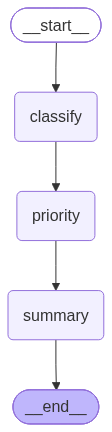

In [7]:
ticket_builder = StateGraph(TicketState)

ticket_builder.add_node("classify", classify_ticket)
ticket_builder.add_node("priority", detect_priority)
ticket_builder.add_node("summary", create_summary)

ticket_builder.add_edge(START, "classify")
ticket_builder.add_edge("classify", "priority")
ticket_builder.add_edge("priority", "summary")
ticket_builder.add_edge("summary", END)

ticket_analysis_graph = ticket_builder.compile()
ticket_analysis_graph
